In [1]:
import re, json, time, warnings, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier, VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f"Imports OK  |  SEED = {SEED}")

Mounted at /content/drive
Imports OK  |  SEED = 42


In [2]:
df_raw = pd.read_csv(os.path.join(DRIVE_DIR, 'cyberbullying_tweets.csv'))
print(f"Raw shape : {df_raw.shape}")

df = (df_raw
      .dropna(subset=['tweet_text', 'cyberbullying_type'])
      .drop_duplicates(subset=['tweet_text'])
      .reset_index(drop=True))

n_removed = len(df_raw) - len(df)
print(f"After dedup : {len(df)} rows  ({n_removed} duplicates removed)")

vc = df['cyberbullying_type'].value_counts()
print("\nLabel distribution (after dedup):")
for cls, cnt in vc.items():
    bar = '█' * int(cnt / 200)
    print(f"  {cls:<22} {cnt:>5}  ({cnt/len(df)*100:.1f}%)  {bar}")

Raw shape : (47692, 2)
After dedup : 46017 rows  (1675 duplicates removed)

Label distribution (after dedup):
  religion                7995  (17.4%)  ███████████████████████████████████████
  age                     7992  (17.4%)  ███████████████████████████████████████
  ethnicity               7952  (17.3%)  ███████████████████████████████████████
  not_cyberbullying       7937  (17.2%)  ███████████████████████████████████████
  gender                  7898  (17.2%)  ███████████████████████████████████████
  other_cyberbullying     6243  (13.6%)  ███████████████████████████████


In [3]:
STOP_EN = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    """
    Preprocessing pipeline for classical ML (TF-IDF):
    lowercase → remove URLs/mentions/hashtags/digits/punctuation → remove stopwords
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+',   ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_EN and len(t) > 1]
    return ' '.join(tokens)

t0 = time.time()
df['clean_text'] = df['tweet_text'].apply(preprocess)
print(f"Preprocessing done in {time.time() - t0:.1f}s")

empty_mask = df['clean_text'].str.len() == 0
df.loc[empty_mask, 'clean_text'] = df.loc[empty_mask, 'tweet_text'].str.lower().fillna('').str.strip()
print(f"Empty after preprocessing (fallback applied): {empty_mask.sum()}")

print("\n Sample (3 random rows)")
for _, row in df.sample(3, random_state=SEED).iterrows():
    print(f"  RAW  : {row['tweet_text'][:75]}")
    print(f"  CLEAN: {row['clean_text'][:75]}\n")

Preprocessing done in 1.1s
Empty after preprocessing (fallback applied): 468

 Sample (3 random rows)
  RAW  : @AndyEaston85 Love how we are teaching the Bullshitters a lesson in footbal
  CLEAN: love teaching bullshitters lesson football miss bully message board posts

  RAW  : GYUK | Anti-feminist YouTuber doubles down on vile Jess Phillips rape joke 
  CLEAN: gyuk anti feminist youtuber doubles vile jess phillips rape joke leaping de

  RAW  : @Truth_Haqq Islam declared war on all mankind 1400 years ago. Now we return
  CLEAN: islam declared war mankind years ago return favor



In [4]:
le           = LabelEncoder()
y_all        = le.fit_transform(df['cyberbullying_type'])
TARGET_NAMES = list(le.classes_)
N_CLASSES    = len(TARGET_NAMES)

print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}  →  {cls}")

idx_all = np.arange(len(df))

idx_tv, idx_te, y_tv, y_te = train_test_split(
    idx_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED
)

idx_tr, idx_val, y_tr, y_val = train_test_split(
    idx_tv, y_tv, test_size=0.125, stratify=y_tv, random_state=SEED
)

print(f"\nSplit summary:")
print(f"  Train : {len(idx_tr):>6}  ({len(idx_tr)/len(df)*100:.1f}%)")
print(f"  Val   : {len(idx_val):>6}  ({len(idx_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(idx_te):>6}  ({len(idx_te)/len(df)*100:.1f}%)")

np.savez(os.path.join(DRIVE_DIR, 'splits.npz'),
    idx_train=idx_tr, idx_val=idx_val, idx_test=idx_te,
    y_train=y_tr,     y_val=y_val,     y_test=y_te,
    label_classes=le.classes_)
df.to_csv(os.path.join(DRIVE_DIR, 'dataset_clean.csv'), index=False, encoding='utf-8')
print("\nsplits.npz + dataset_clean.csv saved")

Label mapping:
  0  →  age
  1  →  ethnicity
  2  →  gender
  3  →  not_cyberbullying
  4  →  other_cyberbullying
  5  →  religion

Split summary:
  Train :  32211  (70.0%)
  Val   :   4602  (10.0%)
  Test  :   9204  (20.0%)

splits.npz + dataset_clean.csv saved


In [5]:
X_tr_raw  = df['clean_text'].values[idx_tr]
X_val_raw = df['clean_text'].values[idx_val]
X_te_raw  = df['clean_text'].values[idx_te]

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

Xtr_v  = tfidf.fit_transform(X_tr_raw)
Xval_v = tfidf.transform(X_val_raw)
Xte_v  = tfidf.transform(X_te_raw)

print(f"Vocabulary size : {len(tfidf.vocabulary_):>8,}")
print(f"Train matrix    : {str(Xtr_v.shape):>18}")
print(f"Val   matrix    : {str(Xval_v.shape):>18}")
print(f"Test  matrix    : {str(Xte_v.shape):>18}")

Vocabulary size :   48,981
Train matrix    :     (32211, 48981)
Val   matrix    :      (4602, 48981)
Test  matrix    :      (9204, 48981)


In [6]:
tier1_defs = {
    'LR' : LogisticRegression(
                C=1.0, solver='lbfgs', max_iter=1000,
                multi_class='multinomial', random_state=SEED),

    'NB' : MultinomialNB(alpha=1.0),

    'SVM': CalibratedClassifierCV(
                LinearSVC(C=1.0, max_iter=2000, random_state=SEED), cv=3),

    'RF' : RandomForestClassifier(
                n_estimators=200, random_state=SEED, n_jobs=-1),

    'KNN': KNeighborsClassifier(
                n_neighbors=5, metric='cosine',
                algorithm='brute', n_jobs=-1),
}

results     = []
trained_t1  = {}
train_times = {}
val_f1_dict = {}

print(f"{'Model':<6} {'Train(s)':>9} {'Val F1':>8} {'Test Acc':>10} {'Test F1':>9}")
print("-" * 50)

for name, clf in tier1_defs.items():
    t0 = time.time()
    clf.fit(Xtr_v, y_tr)
    train_times[name] = time.time() - t0

    val_pred      = clf.predict(Xval_v)
    val_f1        = f1_score(y_val, val_pred, average='macro', zero_division=0)
    val_f1_dict[name] = val_f1

    t1    = time.time()
    pred  = clf.predict(Xte_v)
    inf_t = time.time() - t1

    r = {
        'tier'            : 'Tier 1',
        'model'           : name,
        'accuracy'        : accuracy_score(y_te, pred),
        'precision'       : precision_score(y_te, pred, average='macro', zero_division=0),
        'recall'          : recall_score(y_te, pred, average='macro', zero_division=0),
        'f1'              : f1_score(y_te, pred, average='macro', zero_division=0),
        'train_time_s'    : train_times[name],
        'inference_time_s': inf_t,
    }
    results.append(r)
    trained_t1[name] = clf

    print(f"{name:<6} {train_times[name]:>9.1f} {val_f1:>8.4f} "
          f"{r['accuracy']:>10.4f} {r['f1']:>9.4f}")

preds_all = {n: trained_t1[n].predict(Xte_v) for n in trained_t1}

Model   Train(s)   Val F1   Test Acc   Test F1
--------------------------------------------------
LR          20.8   0.8322     0.8292    0.8190
NB           0.0   0.7059     0.7581    0.7113
SVM          3.6   0.8220     0.8321    0.8216
RF          39.7   0.8328     0.8342    0.8231
KNN          0.0   0.7039     0.6945    0.6927


In [7]:
print("WSV weights (= val F1-macro):")
for n, w in val_f1_dict.items():
    print(f"  {n}: {w:.4f}")

ALL5       = ['LR', 'NB', 'SVM', 'RF', 'KNN']
w_arr      = np.array([val_f1_dict[n] for n in ALL5]).reshape(-1, 1, 1)

t0         = time.time()
probs_all  = np.stack([trained_t1[n].predict_proba(Xte_v) for n in ALL5], axis=0)
p_wsv      = (probs_all * w_arr).sum(axis=0) / w_arr.sum()
pred_wsv   = p_wsv.argmax(axis=1)
inf_wsv    = time.time() - t0

results.append({
    'tier'            : 'Tier 2A',
    'model'           : 'WSV (LR+NB+SVM+RF+KNN)',
    'accuracy'        : accuracy_score(y_te, pred_wsv),
    'precision'       : precision_score(y_te, pred_wsv, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_wsv, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_wsv, average='macro', zero_division=0),
    'train_time_s'    : sum(train_times[n] for n in ALL5),
    'inference_time_s': inf_wsv,
})
r = results[-1]
print(f"\nWSV (2A)  →  Acc={r['accuracy']:.4f}  |  F1={r['f1']:.4f}")

WSV weights (= val F1-macro):
  LR: 0.8322
  NB: 0.7059
  SVM: 0.8220
  RF: 0.8328
  KNN: 0.7039

WSV (2A)  →  Acc=0.8337  |  F1=0.8227


In [8]:
voting_hard = VotingClassifier(
    estimators=[
        ('dt',  DecisionTreeClassifier(random_state=SEED)),
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                               eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                               verbosity=0)),
    ],
    voting='hard',
    n_jobs=-1,
)

print("Training Hard Voting (DT+RF+XGB)...", end=' ', flush=True)
t0 = time.time()
voting_hard.fit(Xtr_v, y_tr)
tt_2b = time.time() - t0
print(f"done ({tt_2b:.1f}s)")

t1 = time.time()
pred_2b = voting_hard.predict(Xte_v)
inf_2b  = time.time() - t1

results.append({
    'tier'            : 'Tier 2B',
    'model'           : 'Hard Voting (DT+RF+XGB)',
    'accuracy'        : accuracy_score(y_te, pred_2b),
    'precision'       : precision_score(y_te, pred_2b, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_2b, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_2b, average='macro', zero_division=0),
    'train_time_s'    : tt_2b,
    'inference_time_s': inf_2b,
})
r = results[-1]
print(f"Hard Voting (2B)  →  Acc={r['accuracy']:.4f}  |  F1={r['f1']:.4f}")

Training Hard Voting (DT+RF+XGB)... done (230.1s)
Hard Voting (2B)  →  Acc=0.8349  |  F1=0.8237


In [9]:
stacking_2c = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                                    multi_class='multinomial', random_state=SEED)),
        ('nb',  MultinomialNB(alpha=1.0)),
        ('svm', CalibratedClassifierCV(
                    LinearSVC(C=1.0, max_iter=2000, random_state=SEED), cv=3)),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)

print("Training Stacking 2C (LR+NB+SVM)...", end=' ', flush=True)
t0 = time.time()
stacking_2c.fit(Xtr_v, y_tr)
tt_2c = time.time() - t0
print(f"done ({tt_2c:.1f}s)")

t1 = time.time()
pred_2c = stacking_2c.predict(Xte_v)
inf_2c  = time.time() - t1

results.append({
    'tier'            : 'Tier 2C',
    'model'           : 'Stacking (LR+NB+SVM)',
    'accuracy'        : accuracy_score(y_te, pred_2c),
    'precision'       : precision_score(y_te, pred_2c, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_2c, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_2c, average='macro', zero_division=0),
    'train_time_s'    : tt_2c,
    'inference_time_s': inf_2c,
})
r = results[-1]
print(f"Stacking 2C  →  Acc={r['accuracy']:.4f}  |  F1={r['f1']:.4f}")

Training Stacking 2C (LR+NB+SVM)... done (25.7s)
Stacking 2C  →  Acc=0.8337  |  F1=0.8233


In [10]:
stacking_2d = StackingClassifier(
    estimators=[
        ('dt',  DecisionTreeClassifier(random_state=SEED)),
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                               eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                               verbosity=0)),
    ],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)

print("Training Stacking 2D (DT+RF+XGB)...", end=' ', flush=True)
t0 = time.time()
stacking_2d.fit(Xtr_v, y_tr)
tt_2d = time.time() - t0
print(f"done ({tt_2d:.1f}s)")

t1 = time.time()
pred_2d = stacking_2d.predict(Xte_v)
inf_2d  = time.time() - t1

results.append({
    'tier'            : 'Tier 2D',
    'model'           : 'Stacking (DT+RF+XGB)',
    'accuracy'        : accuracy_score(y_te, pred_2d),
    'precision'       : precision_score(y_te, pred_2d, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_2d, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_2d, average='macro', zero_division=0),
    'train_time_s'    : tt_2d,
    'inference_time_s': inf_2d,
})
r = results[-1]
print(f"Stacking 2D  →  Acc={r['accuracy']:.4f}  |  F1={r['f1']:.4f}")

Training Stacking 2D (DT+RF+XGB)... done (608.4s)
Stacking 2D  →  Acc=0.8355  |  F1=0.8283


In [11]:
results_df = pd.DataFrame(results)[[
    'tier', 'model', 'accuracy', 'precision', 'recall', 'f1', 'train_time_s'
]].round(4)

print("=" * 100)
print(f"FULL RESULTS — Test Set (n = {len(y_te)})")
print("=" * 100)
print(results_df.to_string(index=False))

for label, pred in [('Stacking 2C (LR+NB+SVM)', pred_2c),
                    ('Stacking 2D (DT+RF+XGB)', pred_2d)]:

    print(f"Classification Report — {label}")
    print('='*65)
    print(classification_report(y_te, pred, target_names=TARGET_NAMES, digits=4))

FULL RESULTS — Test Set (n = 9204)
   tier                   model  accuracy  precision  recall     f1  train_time_s
 Tier 1                      LR    0.8292     0.8218  0.8179 0.8190       20.7707
 Tier 1                      NB    0.7581     0.7396  0.7382 0.7113        0.0142
 Tier 1                     SVM    0.8321     0.8214  0.8220 0.8216        3.6130
 Tier 1                      RF    0.8342     0.8293  0.8213 0.8231       39.6627
 Tier 1                     KNN    0.6945     0.7120  0.6853 0.6927        0.0030
Tier 2A  WSV (LR+NB+SVM+RF+KNN)    0.8337     0.8240  0.8224 0.8227       64.0636
Tier 2B Hard Voting (DT+RF+XGB)    0.8349     0.8323  0.8215 0.8237      230.0813
Tier 2C    Stacking (LR+NB+SVM)    0.8337     0.8239  0.8232 0.8233       25.7413
Tier 2D    Stacking (DT+RF+XGB)    0.8355     0.8304  0.8266 0.8283      608.3671
Classification Report — Stacking 2C (LR+NB+SVM)
                     precision    recall  f1-score   support

                age     0.9458    0

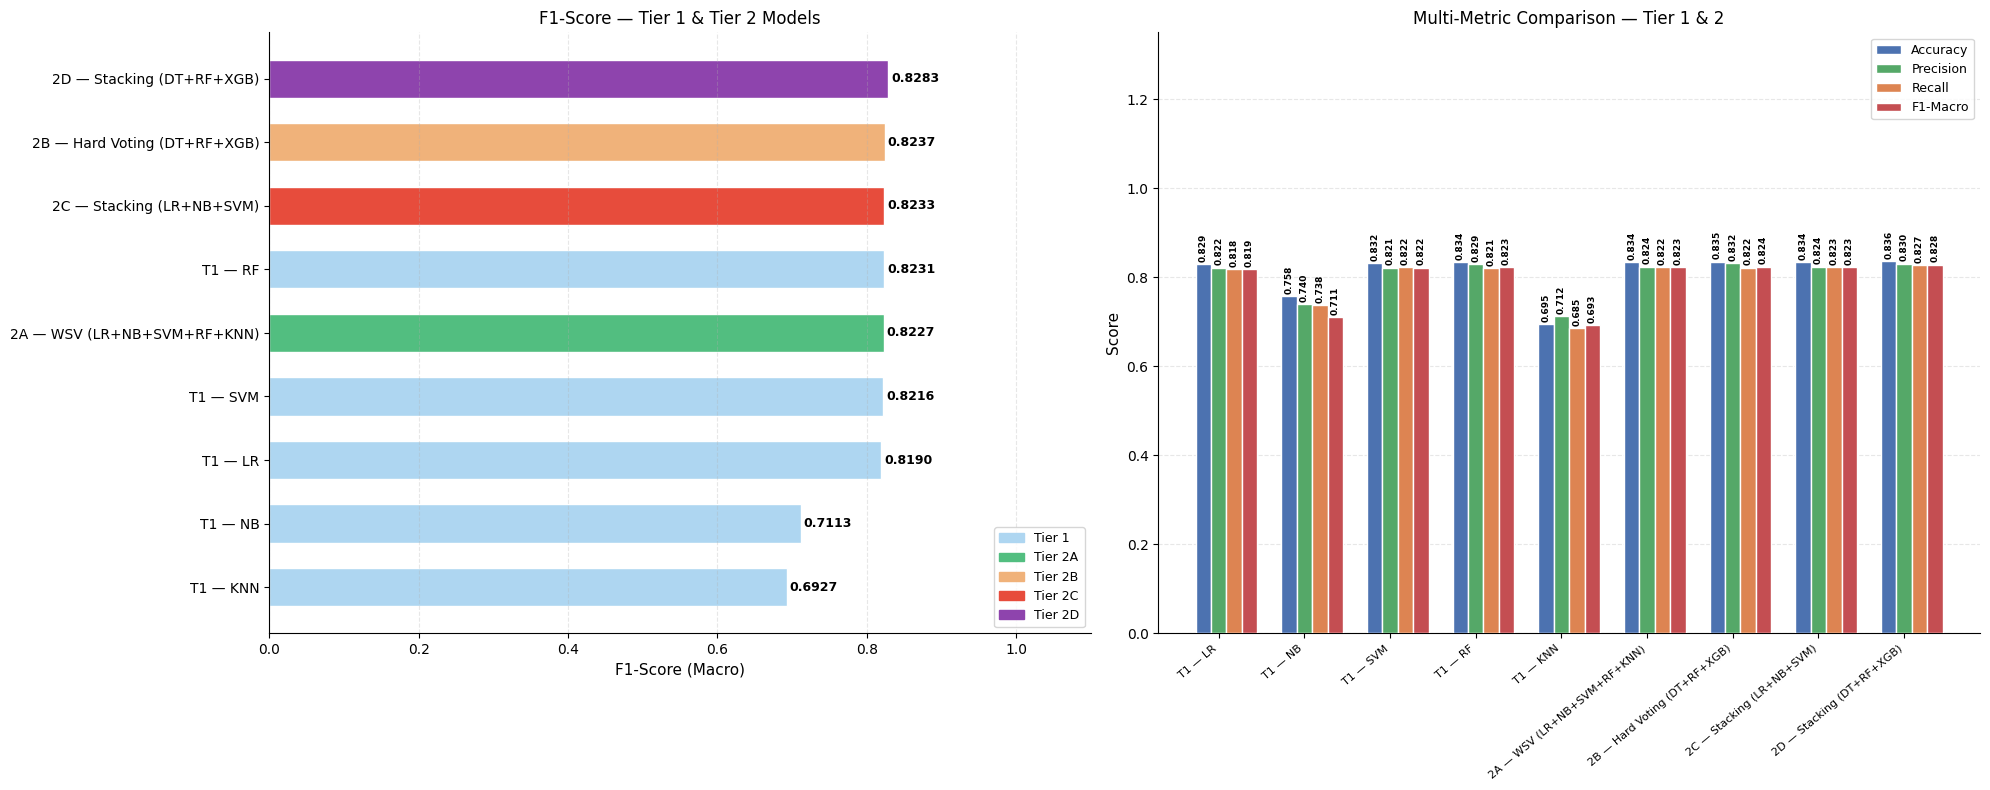

In [12]:
TIER_COLORS = {
    'Tier 1' : '#AED6F1',
    'Tier 2A': '#52BE80',
    'Tier 2B': '#F0B27A',
    'Tier 2C': '#E74C3C',
    'Tier 2D': '#8E44AD',
}

def make_display_label(row):
    tier  = row['tier']
    model = row['model']
    if tier == 'Tier 1':
        return f"T1 — {model}"
    return f"{tier[-2:]} — {model}"

results_df['display'] = results_df.apply(make_display_label, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax1 = axes[0]
rdf_sorted = results_df.sort_values('f1', ascending=True)
bar_colors = [TIER_COLORS[t] for t in rdf_sorted['tier']]
bars = ax1.barh(rdf_sorted['display'], rdf_sorted['f1'],
                color=bar_colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, rdf_sorted['f1']):
    ax1.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('F1-Score (Macro)', fontsize=11)
ax1.set_title('F1-Score — Tier 1 & Tier 2 Models', fontsize=12)
ax1.set_xlim(0, 1.10)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)
patches = [mpatches.Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
ax1.legend(handles=patches, loc='lower right', fontsize=9)

ax2      = axes[1]
METRICS  = ['accuracy', 'precision', 'recall', 'f1']
MET_LBL  = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
MC       = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
x        = np.arange(len(results_df))
w        = 0.18

for i, (m, lbl, color) in enumerate(zip(METRICS, MET_LBL, MC)):
    offset = (i - 1.5) * w + w / 2
    bars2  = ax2.bar(x + offset, results_df[m], w,
                     label=lbl, color=color, edgecolor='white', zorder=3)
    for b, v in zip(bars2, results_df[m]):
        ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom',
                 fontsize=6.5, fontweight='bold', rotation=90)

ax2.set_xticks(x)
ax2.set_xticklabels(results_df['display'], rotation=40, ha='right', fontsize=8)
ax2.set_ylim(0, 1.35)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Multi-Metric Comparison — Tier 1 & 2', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'chart_classical_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

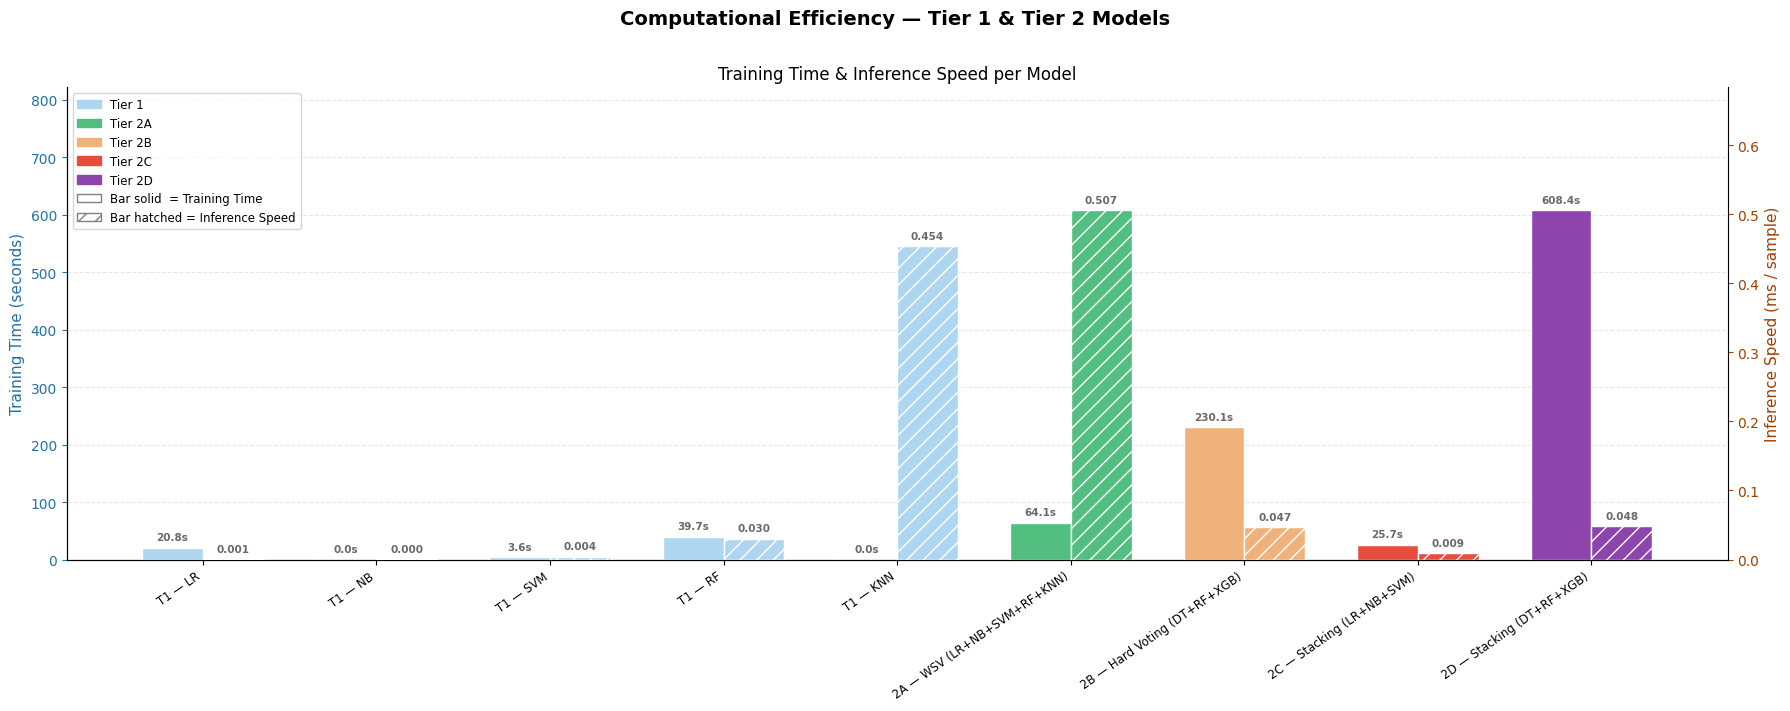

chart_classical_efficiency.png saved


In [13]:
TIER_COLORS = {
    'Tier 1' : '#AED6F1',
    'Tier 2A': '#52BE80',
    'Tier 2B': '#F0B27A',
    'Tier 2C': '#E74C3C',
    'Tier 2D': '#8E44AD',
}

n_test = len(y_te)
eff_df = pd.DataFrame(results).copy()
eff_df['ms_per_sample'] = (eff_df['inference_time_s'] / n_test) * 1000
eff_df['display']       = eff_df.apply(make_display_label, axis=1)
eff_df['color']         = eff_df['tier'].map(TIER_COLORS)

fig, ax1 = plt.subplots(figsize=(18, 7))
fig.suptitle('Computational Efficiency — Tier 1 & Tier 2 Models',
             fontsize=14, fontweight='bold', y=1.01)

n = len(eff_df)
x = np.arange(n)
w = 0.35

bars1 = ax1.bar(
    x - w / 2,
    eff_df['train_time_s'],
    width=w,
    color=eff_df['color'],
    edgecolor='white',
    zorder=3,
    label='Training Time (s)',
)

for bar, val in zip(bars1, eff_df['train_time_s']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + eff_df['train_time_s'].max() * 0.015,
        f'{val:.1f}s', ha='center', va='bottom', fontsize=7.5, fontweight='bold',
        color='dimgray',
    )

ax1.set_ylabel('Training Time (seconds)', fontsize=11)
ax1.set_ylim(0, eff_df['train_time_s'].max() * 1.35)
ax1.yaxis.label.set_color('#2471A3')
ax1.tick_params(axis='y', colors='#2471A3')

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + w / 2,
    eff_df['ms_per_sample'],
    width=w,
    color=eff_df['color'],
    edgecolor='white',
    hatch='//',
    zorder=3,
    label='Inference Speed (ms/sample)',
)

for bar, val in zip(bars2, eff_df['ms_per_sample']):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + eff_df['ms_per_sample'].max() * 0.015,
        f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold',
        color='dimgray',
    )

ax2.set_ylabel('Inference Speed (ms / sample)', fontsize=11)
ax2.set_ylim(0, eff_df['ms_per_sample'].max() * 1.35)
ax2.yaxis.label.set_color('#A04000')
ax2.tick_params(axis='y', colors='#A04000')

ax1.set_xticks(x)
ax1.set_xticklabels(eff_df['display'], rotation=35, ha='right', fontsize=8.5)
ax1.set_title('Training Time & Inference Speed per Model', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)

tier_patches = [
    mpatches.Patch(color=c, label=t)
    for t, c in TIER_COLORS.items()
    if t in eff_df['tier'].values
]
style_patches = [
    mpatches.Patch(facecolor='white', edgecolor='gray',
                   label='Bar solid  = Training Time'),
    mpatches.Patch(facecolor='white', edgecolor='gray', hatch='//',
                   label='Bar hatched = Inference Speed'),
]
ax1.legend(
    handles=tier_patches + style_patches,
    loc='upper left', fontsize=8.5, framealpha=0.8,
)

plt.tight_layout()
plt.savefig(
    os.path.join(DRIVE_DIR, 'chart_classical_efficiency.png'),
    dpi=200, bbox_inches='tight',
)
plt.show()
print("chart_classical_efficiency.png saved")

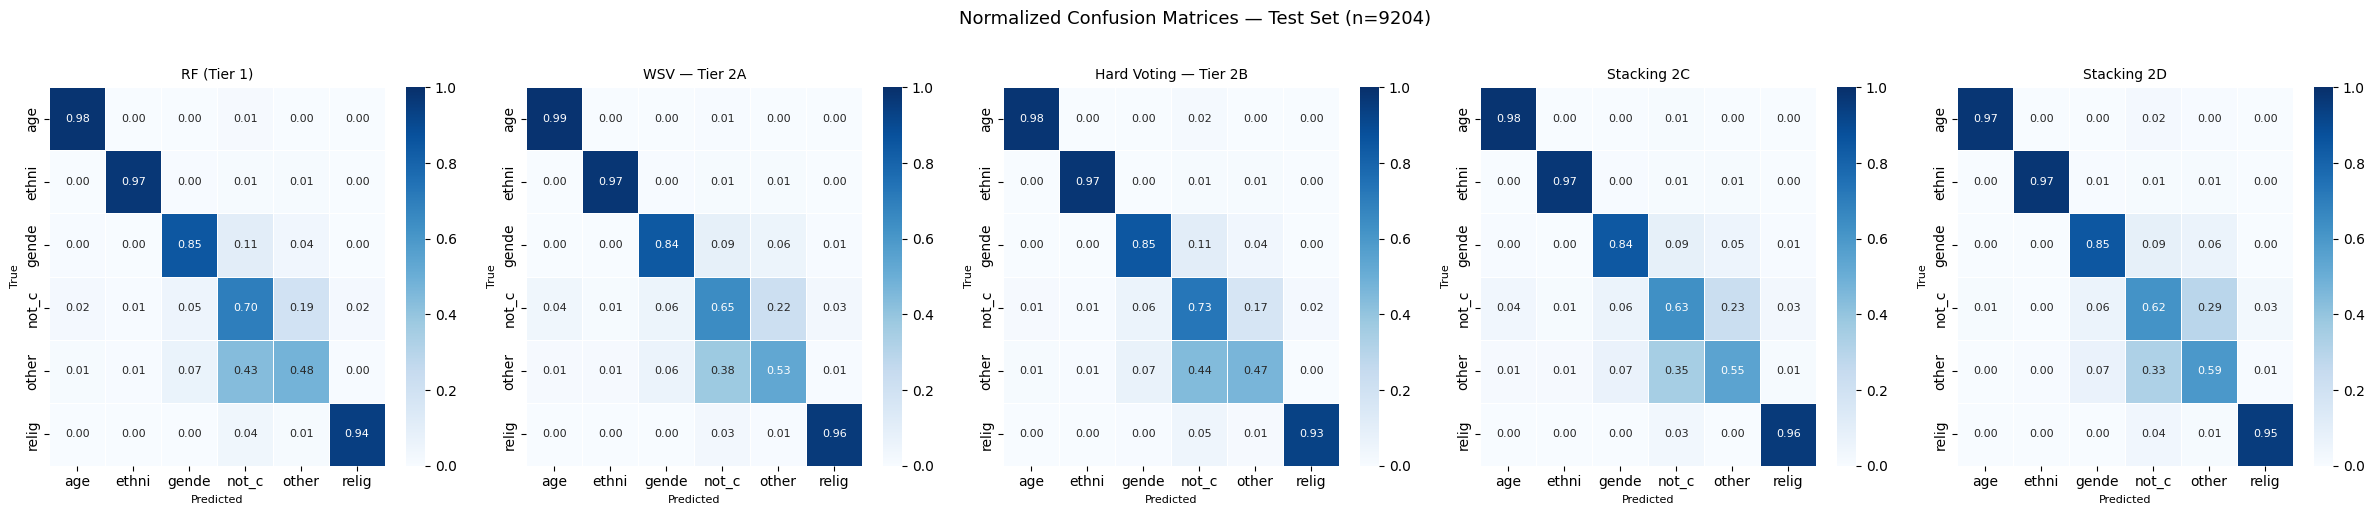

In [14]:
SHORT = [n[:5] for n in TARGET_NAMES]

plot_pairs = [
    ('RF (Tier 1)',             preds_all['RF']),
    ('WSV — Tier 2A',          pred_wsv),
    ('Hard Voting — Tier 2B',  pred_2b),
    ('Stacking 2C',            pred_2c),
    ('Stacking 2D',            pred_2d),
]

fig, axes = plt.subplots(1, len(plot_pairs), figsize=(24, 5))
for ax, (label, pred) in zip(axes, plot_pairs):
    cm_norm = confusion_matrix(y_te, pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=SHORT, yticklabels=SHORT,
                cmap='Blues', vmin=0, vmax=1, linewidths=0.4, annot_kws={'size': 8})
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)

plt.suptitle(f'Normalized Confusion Matrices — Test Set (n={len(y_te)})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'chart_classical_confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

In [15]:
with open(os.path.join(DRIVE_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)
print("tfidf_vectorizer.pkl")

tier1_save = {
    't1_lr' : trained_t1['LR'],
    't1_nb' : trained_t1['NB'],
    't1_svm': trained_t1['SVM'],
    't1_rf' : trained_t1['RF'],
    't1_knn': trained_t1['KNN'],
}
for fname, model in tier1_save.items():
    with open(os.path.join(DRIVE_DIR, f'{fname}.pkl'), 'wb') as f:
        pickle.dump(model, f)
    print(f"{fname}.pkl")

for name, est in voting_hard.named_estimators_.items():
    with open(os.path.join(DRIVE_DIR, f't1_{name}.pkl'), 'wb') as f:
        pickle.dump(est, f)
    print(f"t1_{name}.pkl")

wsv_w = {n: float(val_f1_dict[n]) for n in ['LR', 'NB', 'SVM', 'RF', 'KNN']}
with open(os.path.join(DRIVE_DIR, 'wsv_weights.pkl'), 'wb') as f:
    pickle.dump(wsv_w, f)
print("wsv_weights.pkl")

with open(os.path.join(DRIVE_DIR, 't2b_hard_voting.pkl'), 'wb') as f:
    pickle.dump(voting_hard, f)
print("t2b_hard_voting.pkl")

with open(os.path.join(DRIVE_DIR, 'stacking_2c.pkl'), 'wb') as f:
    pickle.dump(stacking_2c, f)
print(" stacking_2c.pkl")

with open(os.path.join(DRIVE_DIR, 'stacking_2d.pkl'), 'wb') as f:
    pickle.dump(stacking_2d, f)

print("stacking_2d.pkl")

results_df_tmp = pd.DataFrame(results)
best_row = results_df_tmp.loc[results_df_tmp['f1'].idxmax()]
print(f"\nBest classical model: {best_row['model']}  (F1={best_row['f1']:.4f})")

_model_map = {
    **trained_t1,
    'WSV (LR+NB+SVM+RF+KNN)'   : None,
    'Hard Voting (DT+RF+XGB)'  : voting_hard,
    'Stacking (LR+NB+SVM → LR)': stacking_2c,
    'Stacking (DT+RF+XGB)': stacking_2d,
}
best_obj = _model_map.get(best_row['model'])

if best_obj is None:
    print(" Best model is WSV (no single pkl). Saving Stacking 2C as fallback.")
    best_obj = stacking_2c
    best_row_model = 'Stacking (LR+NB+SVM)'
else:
    best_row_model = best_row['model']

with open(os.path.join(DRIVE_DIR, 'best_classical_ml.pkl'), 'wb') as f:
    pickle.dump(best_obj, f)
with open(os.path.join(DRIVE_DIR, 'best_classical_ml_name.txt'), 'w') as f:
    f.write(best_row_model)
print(f" best_classical_ml.pkl {best_row_model}")

json_output = {'results': results}
with open(os.path.join(DRIVE_DIR, 'classical_ml_output.json'), 'w') as f:
    json.dump(json_output, f, indent=2)
print(" classical_ml_output.json")

results_df.to_csv(os.path.join(DRIVE_DIR, 'classical_ml_results.csv'), index=False)
print(" classical_ml_results.csv")

tfidf_vectorizer.pkl
t1_lr.pkl
t1_nb.pkl
t1_svm.pkl
t1_rf.pkl
t1_knn.pkl
t1_dt.pkl
t1_rf.pkl
t1_xgb.pkl
wsv_weights.pkl
t2b_hard_voting.pkl
 stacking_2c.pkl
stacking_2d.pkl

Best classical model: Stacking (DT+RF+XGB)  (F1=0.8283)
 best_classical_ml.pkl Stacking (DT+RF+XGB)
 classical_ml_output.json
 classical_ml_results.csv
